## Differentiable acoustic medium & attenuation

This notebook shows, in isolation, how the speed-of-sound and air-attenuation functions can be used in gradient-based optimization -- without a full scene-optimization setup. For an introduction to differentiable rendering itself (scene parameters, `Optimizer`, `traverse`), see [material_optimization.ipynb](../inverse_rendering/material_optimization.ipynb) first.

## Overview

Under an `*_ad_*` variant, three pieces of the acoustic pipeline carry gradients:

1. **`mitsuba.acoustic.speed_of_sound()`** -- gradients on `temperature`, `relative_humidity`, `atmospheric_pressure`, `saturation_vapor_pressure` or `co2_ppm` propagate through to the returned speed of sound.
2. **`mitsuba.acoustic.energy_attenuation_coefficient()`** and **`mitsuba.acoustic.apply_pure_tone_attenuation()`** -- the ISO 9613-1 air-attenuation coefficient, and a ready-to-use post-processing step that applies it to a rendered ETC; both differentiable in the same medium parameters.
3. **The `acoustic_medium` parameters of `acoustic_prb`** -- exposed via `mitsuba.traverse()`, so an `Optimizer` can recover atmospheric conditions (e.g. temperature) from an observed echogram, the same way [material_optimization.ipynb](../inverse_rendering/material_optimization.ipynb) recovers material coefficients.

**Part 1** below exercises (1) and (2) directly, with no scene or rendering involved. **Part 2** builds a minimal scene and uses (3) to recover an unknown air temperature by gradient descent.

<div class="admonition important alert alert-block alert-warning">

⚠️ **Caution:**

The `speed_of_sound` used by the *inline* renderer (`acoustic_prb`, `acoustic_ad`) is **not yet differentiable through the rendering itself**: it decides which time bin a path's energy is written to, and splatting into an `ImageBlock` is not differentiable with respect to the splat *position* in this Mitsuba build. Changing `speed_of_sound` therefore does not currently produce a gradient through `mitsuba.render()`.

The energy *attenuation* (item 2/3 above) has no such limitation -- it only scales the energy written to an (already-fixed) time bin, which is fully differentiable. Part 2 below sets `speed_of_sound` explicitly (bypassing `acoustic_medium` for timing) and optimizes `temperature` purely through its effect on attenuation.

</div>

## Setup

As with any differentiable pipeline, we need a variant that supports automatic differentiation (`_ad_` in the name), e.g. `cuda_ad_acoustic` or `llvm_ad_acoustic`.

In [52]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format='svg'

from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

import drjit as dr
import mitsuba as mi
mi.set_variant('cuda_ad_acoustic', 'llvm_ad_acoustic')
from mitsuba import ScalarTransform4f as tf

seed = 0

## Part 1: Differentiating the standalone functions

Every input can carry a gradient. We enable a gradient on `temperature`, call the function, and use forward-mode AD (`dr.forward`) to read out the derivative. A central finite difference confirms the result.

### `speed_of_sound`

In [53]:
temperature = mi.Float(20.0)
dr.enable_grad(temperature)

c = mi.acoustic.speed_of_sound(temperature=temperature,
                                relative_humidity=mi.Float(0.5),
                                atmospheric_pressure=mi.Float(101325.0),
                                method='cramer')
dr.forward(temperature)

print(f'speed_of_sound(20°C)     = {c[0]:.4f} m/s')
print(f'AD d(speed_of_sound)/dT  = {dr.grad(c)[0]:.6f} (m/s)/°C')

# Finite-difference check
def speed_of_sound(T):
    return mi.acoustic.speed_of_sound(temperature=mi.Float(T),
                                       relative_humidity=mi.Float(0.5),
                                       atmospheric_pressure=mi.Float(101325.0),
                                       method='cramer')[0]

eps = 0.01
fd = (speed_of_sound(20.0 + eps) - speed_of_sound(20.0 - eps)) / (2 * eps)
print(f'FD d(speed_of_sound)/dT  = {fd:.6f} (m/s)/°C')

speed_of_sound(20°C)     = 343.9816 m/s
AD d(speed_of_sound)/dT  = 0.624467 (m/s)/°C
FD d(speed_of_sound)/dT  = 0.622559 (m/s)/°C


### `energy_attenuation_coefficient`

The air-absorption coefficient used internally by `acoustic_prb`'s inline attenuation.

In [54]:
temperature = mi.Float(20.0)
dr.enable_grad(temperature)

alpha = mi.acoustic.energy_attenuation_coefficient(
    temperature=temperature, frequency=mi.Float(8000.0),
    relative_humidity=mi.Float(0.5), atmospheric_pressure=mi.Float(101325.0))
dr.forward(temperature)

print(f'alpha(20°C, 8 kHz)  = {alpha[0]:.6f} 1/m')
print(f'AD d(alpha)/dT      = {dr.grad(alpha)[0]:.8f} (1/m)/°C')

def alpha_fn(T):
    return mi.acoustic.energy_attenuation_coefficient(
        temperature=mi.Float(T), frequency=mi.Float(8000.0),
        relative_humidity=mi.Float(0.5), atmospheric_pressure=mi.Float(101325.0))[0]

fd = (alpha_fn(20.0 + eps) - alpha_fn(20.0 - eps)) / (2 * eps)
print(f'FD d(alpha)/dT      = {fd:.8f} (1/m)/°C')

alpha(20°C, 8 kHz)  = 0.024244 1/m
AD d(alpha)/dT      = -0.00101328 (1/m)/°C
FD d(alpha)/dT      = -0.00101393 (1/m)/°C


### `apply_pure_tone_attenuation` (post-processing)

This is a drop-in post-processing step for the output of `mitsuba.render()`: it accepts a `TensorXf` and returns one of the same shape. If the input tensor carries a gradient (e.g. it *is* the attached output of `mitsuba.render()`), that gradient propagates through together with the medium parameters'.

In [55]:
n_time_bins, n_freq = 50, 2
etc = mi.TensorXf(np.ones((n_time_bins, n_freq), dtype=np.float32))

temperature = mi.Float(20.0)
dr.enable_grad(temperature)

etc_attenuated = mi.acoustic.apply_pure_tone_attenuation(
    etc=etc, sampling_rate=mi.Float(1000.0), speed_of_sound_ms=mi.Float(343.0),
    temperature=temperature, frequencies=[mi.Float(1000.0), mi.Float(8000.0)],
    relative_humidity=mi.Float(0.5), atmospheric_pressure=mi.Float(101325.0))

print('gradient attached to output:', dr.grad_enabled(etc_attenuated))

loss = dr.sum(etc_attenuated.array)
dr.backward(loss)
print(f'd(sum(etc_attenuated))/dT = {dr.grad(temperature)[0]:.6f}')

gradient attached to output: True
d(sum(etc_attenuated))/dT = 0.310323


## Part 2: Recovering air temperature from an echogram

We now use these gradients inside an actual rendering: a minimal scene with a single sound source and no reflecting geometry (`max_depth=1`, direct sound only), so that the *only* effect `temperature` can have on the render is through air attenuation (see the warning above).

We render a reference ETC at the true air temperature, then use gradient descent to recover it starting from a wrong initial guess -- exactly the `traverse()` / `Optimizer` pattern from [material_optimization.ipynb](../inverse_rendering/material_optimization.ipynb), applied to `acoustic_medium` instead of a BSDF.

### Scene

A single sound source, far from the microphone: the larger the distance, the more the accumulated attenuation (and hence its gradient) affects the received energy. We also pick a high frequency (8 kHz): attenuation grows with frequency, giving a much stronger gradient signal than e.g. 1 kHz.

In [56]:
distance = 20.0  # meters between microphone and speaker
radius   = 3.0   # speaker size, large enough for a reasonable hit rate

scene = mi.load_dict({
    'type': 'scene',
    'speaker': {
        'type': 'sphere',
        'center': [distance, 0, 0],
        'radius': radius,
        'emitter': {
            'type': 'area',
            'radiance': {'type': 'uniform', 'value': 1000.},
        },
    },
})

In [57]:
max_time      = 0.1
sampling_rate = 8000
t_bins        = int(max_time * sampling_rate)

microphone = mi.load_dict({
    'type': 'microphone',
    'origin': [0, 0, 0],
    'direction': [distance, 0, 0],  # look at the speaker
    'film': {
        'type': 'tape',
        'frequencies': '1000, 8000',
        'time_bins': t_bins,
        'rfilter': {'type': 'box'},
    },
})

### Integrator

`speed_of_sound` is set **explicitly** (fixed, not part of `acoustic_medium`), so that changing `medium_temperature` later only affects attenuation -- isolating exactly the gradient path that works today (see the warning above).

In [58]:
relative_humidity     = 0.5
atmospheric_pressure  = 101325.0

def make_integrator(temperature):
    return mi.load_dict({
        'type': 'acoustic_prb',
        'max_depth': 1,        # direct sound only
        'max_time': max_time,
        'speed_of_sound': 343.0,  # fixed on purpose, see warning above
        'acoustic_medium': {
            'temperature': temperature,
            'relative_humidity': relative_humidity,
            'atmospheric_pressure': atmospheric_pressure,
        },
    })

### Reference ETC

Rendered at the (unknown, to-be-recovered) true air temperature.

In [59]:
true_temperature = 35.0

spp_ref = 2**20
integrator_ref = make_integrator(true_temperature)
etc_ref = mi.render(scene, sensor=microphone, integrator=integrator_ref, spp=spp_ref, seed=seed) / spp_ref

2026-09-04 15:24:39 WARN main [acoustic_ad.py:190] __init__(): Both "speed_of_sound" and "acoustic_medium" were specified: the explicit "speed_of_sound" value (343.0) is used, "acoustic_medium" is ignored for the speed of sound.

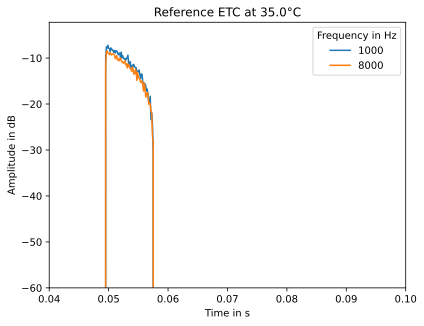

In [60]:
def plot_etc(etc: mi.TensorXf, sampling_rate: int, max_time: float,
             dB: bool = True, bottom: float = -100, ax=None, **kwargs):
    """Plot Energy Time Curve"""
    times = np.arange(max_time, step=1 / sampling_rate)
    etc = etc.numpy().squeeze()

    if ax is None:
        ax = plt.gca()
    ax.set_xlabel('Time in s')
    ax.set_ylabel('Amplitude')

    if dB:
        with np.errstate(divide='ignore'):
            etc = 10 * np.nan_to_num(np.log10(np.abs(etc)), neginf=-300)
        ax.set_ylabel('Amplitude in dB')

    ax.plot(times, etc, **kwargs)
    ax.set_xlim(0.04, max_time)
    ax.set_ylim(bottom=bottom, top=np.max(etc) + 5)

plot_etc(etc_ref, sampling_rate, max_time, bottom=-60, label=[1000, 8000])

plt.legend(title='Frequency in Hz')
plt.title(f'Reference ETC at {true_temperature}°C')
plt.show()

### Optimization loop

We start from a deliberately wrong initial guess and use `mi.traverse()` to expose `medium_temperature` as an optimizable scene parameter -- the same mechanism used for material coefficients in [material_optimization.ipynb](../inverse_rendering/material_optimization.ipynb).

Both renders (the fixed-temperature reference and the current guess) use the **same seed** at every iteration (only the seed changes *across* iterations, for a fresh noise pattern each time). Since ray/path sampling depends only on the seed and scene structure, not on `temperature`, this "common random numbers" trick makes both renders trace the *same* paths -- only the attenuation-driven amplitude differs. Their Monte Carlo noise is therefore strongly correlated and cancels out in the loss, instead of adding two independent noise terms.

In [61]:
initial_temperature = 10.0

opt = mi.ad.Adam(lr=0.5)
opt['temperature'] = mi.Float(initial_temperature)

integrator = make_integrator(initial_temperature)
params = mi.traverse(integrator)

def update(opt, params):
    opt['temperature'] = dr.clip(opt['temperature'], -50.0, 50.0)
    params['medium_temperature'] = opt['temperature']
    params.update(opt)

update(opt, params)

2026-09-04 15:24:41 WARN main [acoustic_ad.py:190] __init__(): Both "speed_of_sound" and "acoustic_medium" were specified: the explicit "speed_of_sound" value (343.0) is used, "acoustic_medium" is ignored for the speed of sound.

In [62]:
spp_opt = 2**19
iteration_count = 300

# IGNORE THIS: When running under pytest, adjust parameters to reduce computation time
import os
if 'PYTEST_CURRENT_TEST' in os.environ:
    iteration_count = 2

In [63]:
temperatures = np.empty(iteration_count)
losses = np.empty(iteration_count)

for i in range(iteration_count):
    it_seed = seed + i

    # Common random numbers: same seed for both renders, so they trace the
    # same paths and only differ in the (deterministic) attenuation factor.
    etc_ref_i = mi.render(scene, sensor=microphone, integrator=integrator_ref,
                          spp=spp_opt, seed=it_seed) / spp_opt
    etc = mi.render(scene, params, integrator=integrator, sensor=microphone,
                     spp=spp_opt, seed=it_seed) / spp_opt

    loss = dr.mean(dr.square(etc - etc_ref_i))

    temperatures[i] = opt['temperature'].array[0]
    losses[i] = loss.array[0]

    dr.backward(loss)
    opt.step()
    update(opt, params)

print(f'Recovered temperature: {temperatures[-1]:.2f}°C (true: {true_temperature}°C)')

Recovered temperature: 34.53°C (true: 35.0°C)


### Results

The optimizer has no information about temperature other than the (noisy) attenuation-driven energy loss at each frequency -- yet it recovers a value close to the true air temperature.

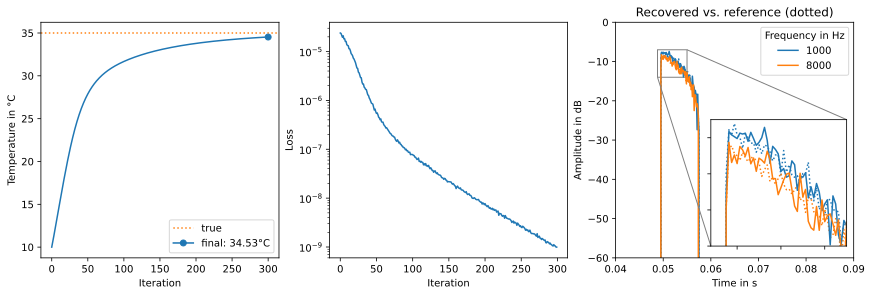

In [64]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4), layout='constrained')

ax1.plot(temperatures)
ax1.axhline(true_temperature, linestyle='dotted', color='C1', label='true')
ax1.plot(300, temperatures[-1], marker='o', color='C0', label=f'final: {temperatures[-1]:.2f}°C')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Temperature in °C')
ax1.legend()

ax2.semilogy(losses)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Loss')

from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

plot_etc(etc_ref, sampling_rate, max_time, bottom=-60, ax=ax3,
         linestyle='dotted', label='_nolabel')
ax3.set_prop_cycle(None)
plot_etc(etc, sampling_rate, max_time, bottom=-60, ax=ax3, label=[1000, 8000])
ax3.set_xlim(0.04, 0.09)
ax3.set_ylim(-60, 0)
ax3.legend(title='Frequency in Hz', loc='upper right')
ax3.set_title('Recovered vs. reference (dotted)')

x1, x2, y1, y2 = 0.0488, 0.055, -14, -7
axins = zoomed_inset_axes(ax3, zoom=4.6, loc='lower left',
                          bbox_to_anchor=(0.06, -57),
                          bbox_transform=ax3.transData, borderpad=0)

plot_etc(etc_ref, sampling_rate, max_time, bottom=-60, ax=axins,
         linestyle='dotted', label='_nolabel')
axins.set_prop_cycle(None)
plot_etc(etc, sampling_rate, max_time, bottom=-60, ax=axins, label='_nolabel')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
axins.set_xlabel('')
axins.set_ylabel('')
axins.tick_params(labelbottom=False, labelleft=False)

mark_inset(ax3, axins, loc1=1, loc2=3, fc='none', ec='0.5')

plt.show()